# Machine Learning Algorithms: SVM & PCA

### Supervised vs. Unsupervised Learning
- **Support Vector Machines (SVM)** is a **Supervised** learning algorithm used for classification and regression.
- **Principal Component Analysis (PCA)** is an **Unsupervised** learning algorithm used for dimensionality reduction and feature extraction.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC, SVR
from sklearn.datasets import make_blobs, make_moons, load_digits, load_sample_image
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

---
## Part 1: Support Vector Machines (Supervised Learning)
### 1.1 Linear SVM for Classification
Here we will create two easily separable clusters and use a Linear Kernel to draw the optimal hyperplane between them.

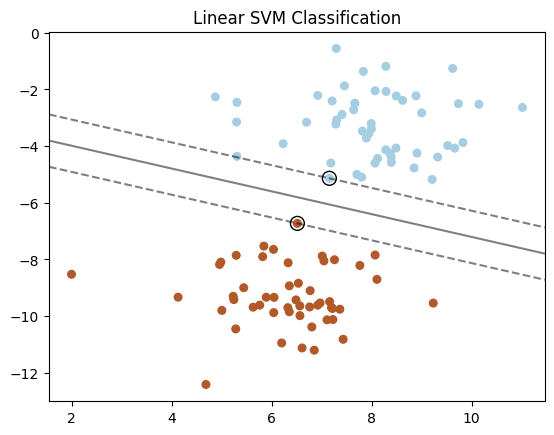

In [4]:
# Generate linearly separable data
X_lin, y_lin = make_blobs(n_samples=100, centers=2, random_state=6, cluster_std=1.2)

# Fit the Linear SVM Model
clf_linear = SVC(kernel='linear', C=1.0)
clf_linear.fit(X_lin, y_lin)

# Plotting function
def plot_svm_boundary(model, X, y, title):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=plt.cm.Paired)
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # Create grid to evaluate model
    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = model.decision_function(xy).reshape(XX.shape)
    
    # Plot decision boundary and margins
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5, 
               linestyles=['--', '-', '--'])
    # Plot support vectors
    ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=100, 
               linewidth=1, facecolors='none', edgecolors='k')
    plt.title(title)
    plt.show()

plot_svm_boundary(clf_linear, X_lin, y_lin, 'Linear SVM Classification')

### 1.2 Kernel Methods (Non-Linear SVM)
Real-world data is rarely linearly separable. We use the **Kernel Trick** (e.g., RBF - Radial Basis Function) to separate complex, intertwined data.

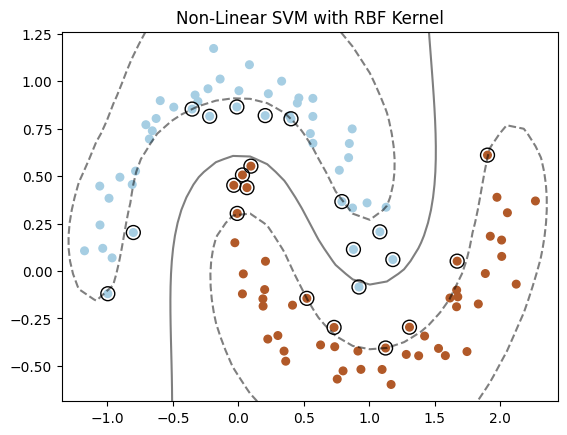

In [5]:
# Generate non-linear "moon" shaped data
X_moon, y_moon = make_moons(n_samples=100, noise=0.1, random_state=42)

# Fit SVM with RBF Kernel
clf_rbf = SVC(kernel='rbf', C=1.0, gamma=1.5)
clf_rbf.fit(X_moon, y_moon)

plot_svm_boundary(clf_rbf, X_moon, y_moon, 'Non-Linear SVM with RBF Kernel')

### 1.3 SVM for Regression (SVR)
Instead of separating classes, SVR tries to fit the best line/curve within a certain margin of tolerance.

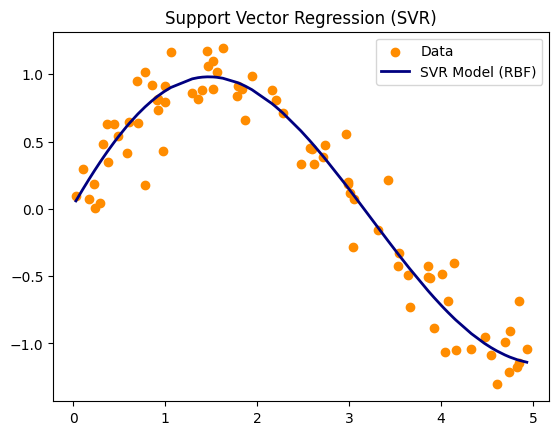

In [6]:
# Generate a noisy sine wave for regression
np.random.seed(42)
X_reg = np.sort(5 * np.random.rand(80, 1), axis=0)
y_reg = np.sin(X_reg).ravel() + 0.2 * np.random.randn(80)

# Train SVR Model
svr_rbf = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
y_pred = svr_rbf.fit(X_reg, y_reg).predict(X_reg)

# Plotting
plt.scatter(X_reg, y_reg, color='darkorange', label='Data')
plt.plot(X_reg, y_pred, color='navy', lw=2, label='SVR Model (RBF)')
plt.title('Support Vector Regression (SVR)')
plt.legend()
plt.show()

---
## Part 2: Principal Component Analysis (Unsupervised Learning)
### 2.1 Visualization and Interpretation
We will load a dataset of 8x8 pixel images of handwritten digits (64 dimensions!). Using PCA, we will compress these 64 features into just 2 components so we can view them on a 2D plot.

## Main reasons for dimensionality reduction
1. **Avoid the "Curse of Dimensionality"** – More features → sparser data, distances lose meaning.  
2. **Improve computational efficiency** – Fewer dimensions = faster training, less memory.  
3. **Enable visualization** – Reduce to 2D/3D to spot clusters & outliers.  
4. **Reduce overfitting** – Keep strong signals, drop noise → better generalisation.  
5. **Remove multicollinearity** – PCA makes uncorrelated components, stabilising linear models.  
6. **Noise reduction** – Small‑variance components often capture noise; discarding them helps.

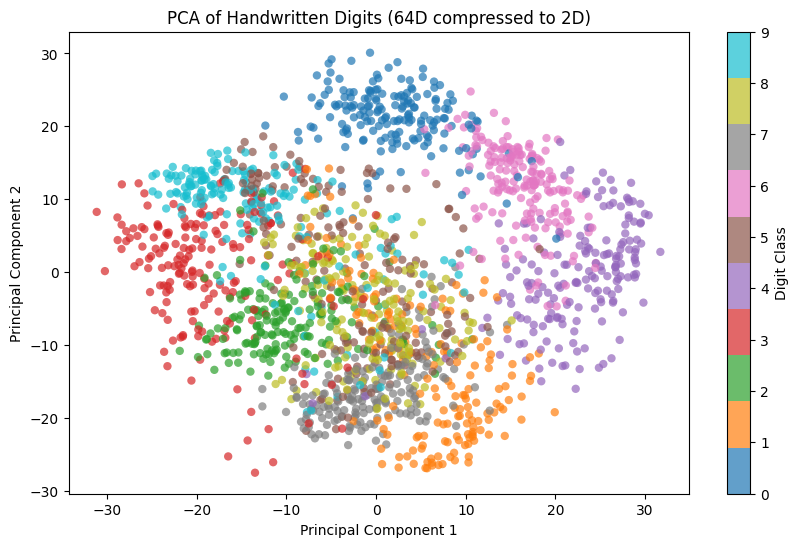

Variance retained by 2 components: 28.51%


In [7]:
# Load Digits Dataset (64 dimensions)
digits = load_digits()
X_digits = digits.data
y_digits = digits.target

# Initialize and apply PCA to reduce 64 features down to 2
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_digits)

# Plot the PCA Results
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_digits, cmap='tab10', alpha=0.7, edgecolors='none')
plt.colorbar(scatter, label='Digit Class')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Handwritten Digits (64D compressed to 2D)')
plt.show()

print(f"Variance retained by 2 components: {sum(pca_2d.explained_variance_ratio_) * 100:.2f}%")

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X_pca, y_digits, test_size=0.3, random_state=42)

clf = LogisticRegression(max_iter=5000)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.6203703703703703


In [9]:
clf.predict_proba(X_test)

array([[1.87796192e-02, 2.92415435e-03, 9.14421662e-06, ...,
        4.01414106e-05, 5.15856402e-03, 1.86199347e-04],
       [3.36453337e-04, 1.03174636e-03, 2.06463678e-01, ...,
        3.33093523e-03, 6.51137423e-02, 3.90871377e-01],
       [7.25877728e-07, 4.98336941e-05, 1.59676079e-01, ...,
        8.68014660e-04, 5.47928355e-03, 8.22825192e-02],
       ...,
       [9.82991603e-01, 2.41204776e-05, 5.51880550e-05, ...,
        2.08493170e-06, 1.64380269e-03, 6.35437707e-03],
       [1.43667307e-09, 1.52674876e-01, 1.75971523e-01, ...,
        4.79885368e-01, 1.21072188e-01, 3.70917649e-03],
       [4.39111110e-02, 2.70790422e-03, 1.44121200e-05, ...,
        4.18612675e-05, 6.62127549e-03, 3.60429607e-04]])

In [10]:

import numpy as np

digit_1 = np.array([
    [0,0,0,12,16,0,0,0],
    [0,0,0,13,14,0,0,0],
    [0,0,0,12,16,0,0,0],
    [0,0,0,12,16,0,0,0],
    [0,0,0,12,16,0,0,0],
    [0,0,0,12,16,0,0,0],
    [0,0,0,12,16,0,0,0],
    [0,0,0,12,16,0,0,0]
])

In [11]:
new_digit_flat = digit_1.reshape(1, -1)

In [12]:
new_digit_pca = pca_2d.transform(new_digit_flat)

In [13]:
prediction = clf.predict(new_digit_pca)
print("Predicted digit:", prediction[0])

Predicted digit: 7


In [14]:
arr =clf.predict_proba(new_digit_pca)
arr_rounded = np.round(arr, 2)
print(arr_rounded)

[[0.   0.38 0.01 0.   0.   0.01 0.   0.57 0.03 0.  ]]


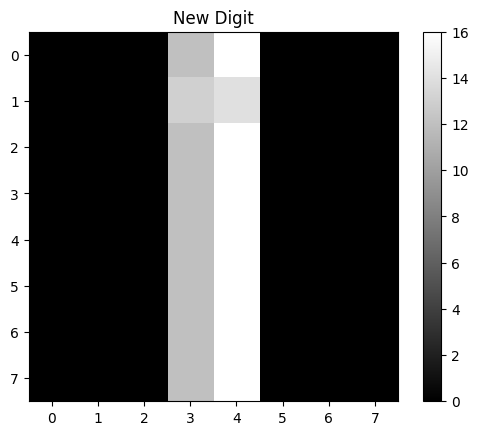

In [15]:
plt.imshow(digit_1, cmap='gray')
plt.title("New Digit")
plt.colorbar()
plt.show()

In [16]:
digit_2 = np.array([
    [0,0,7,15,13,1,0,0],
    [0,4,16,13,16,3,0,0],
    [0,5,16,5,15,8,0,0],
    [0,0,3,0,13,10,0,0],
    [0,0,0,2,16,6,0,0],
    [0,0,1,12,12,0,0,0],
    [0,0,8,16,16,10,8,0],
    [0,0,6,12,8,0,0,0]
])

In [17]:
digit_2_flat = digit_2.reshape(1, -1)
digit_2_pca = pca_2d.transform(digit_2_flat)
prediction = clf.predict(digit_2_pca)

print("Predicted digit:", prediction[0])

Predicted digit: 2


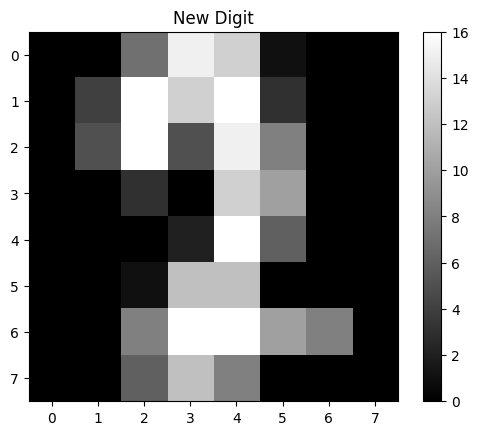

In [18]:
plt.imshow(digit_2, cmap='gray')
plt.title("New Digit")
plt.colorbar()
plt.show()

In [19]:
digit_3 = np.array([
    [0,0,7,14,14,2,0,0],
    [0,2,16,12,16,4,0,0],
    [0,0,0,0,15,6,0,0],
    [0,0,0,5,16,6,0,0],
    [0,0,0,0,15,7,0,0],
    [0,0,0,0,16,6,0,0],
    [0,1,12,16,14,5,0,0],
    [0,0,6,14,10,0,0,0]
])

In [20]:
digit_3_flat = digit_3.reshape(1, -1)
digit_3_pca = pca_2d.transform(digit_3_flat)
prediction = clf.predict(digit_3_pca)

print("Predicted digit:", prediction[0])

Predicted digit: 2


In [25]:
digit_3_pca

array([[-12.68358591, -13.26988596]])

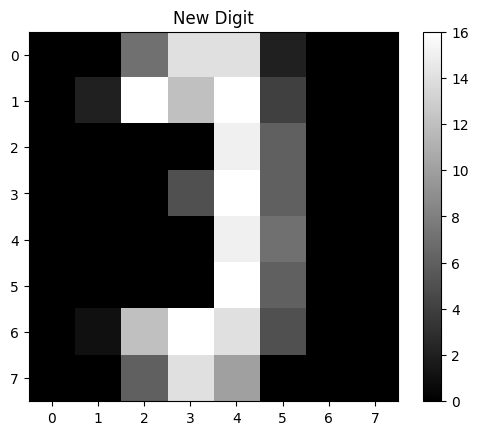

In [21]:
plt.imshow(digit_3, cmap='gray')
plt.title("New Digit")
plt.colorbar()
plt.show()

In [22]:
arr =clf.predict_proba(digit_3_pca)
arr_rounded = np.round(arr, 2)
print(arr_rounded)

[[0.   0.01 0.5  0.28 0.   0.03 0.   0.1  0.05 0.02]]


### 2.2 Image Compression using PCA
An image is just a massive matrix of pixels. We can apply PCA to extract the "Principal Components" (the most important shapes/lighting) of an image and discard the rest. This heavily compresses the image while retaining visual quality.

Original Image Shape: (427, 640)


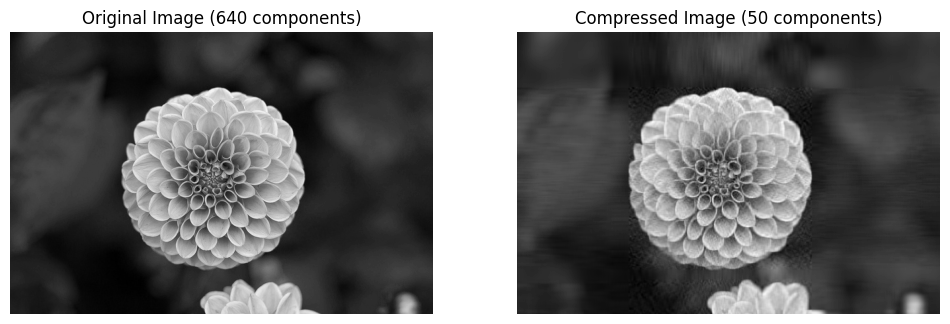

By keeping only 50 components, we retain 98.21% of the original image's information!


In [23]:
# Load sample scikit-learn image and convert to grayscale
china = load_sample_image("flower.jpg")
china_gray = china.mean(axis=2) # Convert to 2D grayscale array

print(f"Original Image Shape: {china_gray.shape}") # e.g., (427, 640)

# Apply PCA to compress the image (keeping only top 50 components out of 640)
pca_img = PCA(n_components=50)
china_compressed = pca_img.fit_transform(china_gray)

# Reconstruct the image from the compressed version
china_reconstructed = pca_img.inverse_transform(china_compressed)

# Visualizing Original vs Compressed
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(china_gray, cmap='gray')
axes[0].set_title('Original Image (640 components)')
axes[0].axis('off')

axes[1].imshow(china_reconstructed, cmap='gray')
axes[1].set_title('Compressed Image (50 components)')
axes[1].axis('off')

plt.show()

variance_retained = sum(pca_img.explained_variance_ratio_) * 100
print(f"By keeping only 50 components, we retain {variance_retained:.2f}% of the original image's information!")

In [26]:
china_compressed

array([[-2.05843287e+03, -9.44881096e+02,  2.43748827e+02, ...,
         6.14113778e+00,  3.15047105e+00,  4.31212233e+00],
       [-2.06058911e+03, -9.44954828e+02,  2.42823253e+02, ...,
         4.85254056e+00,  3.17576907e+00,  4.44461446e+00],
       [-2.06106047e+03, -9.47407322e+02,  2.39454177e+02, ...,
         5.52734912e+00,  3.30775298e+00,  4.22255850e+00],
       ...,
       [ 2.35282227e+03, -7.48251515e+02, -2.15564416e+02, ...,
        -8.93058492e+01,  1.07132173e+02,  4.35197535e+01],
       [ 2.41280844e+03, -8.54441936e+02, -2.86269697e+02, ...,
        -9.06142346e+01,  1.44991058e+01,  1.01569845e+02],
       [ 2.38558378e+03, -8.00109545e+02, -2.51399298e+02, ...,
        -9.08172674e+01, -1.56641346e+00,  8.96624016e+01]])

Original Image Shape: (427, 640)


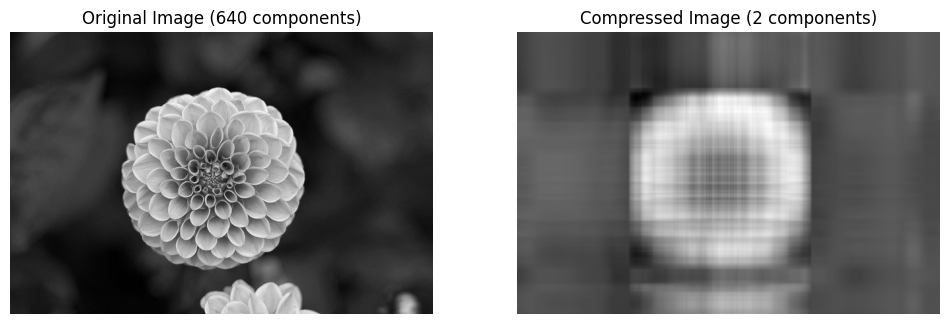

By keeping only 2 components, we retain 62.42% of the original image's information!


In [29]:
# Load sample scikit-learn image and convert to grayscale
china = load_sample_image("flower.jpg")
china_gray = china.mean(axis=2) # Convert to 2D grayscale array


print(f"Original Image Shape: {china_gray.shape}") # e.g., (427, 640)

# Apply PCA to compress the image (keeping only top 50 components out of 640)
pca_img = PCA(n_components=2)
china_compressed_compressed = pca_img.fit_transform(china_gray)

# Reconstruct the image from the compressed version
china_reconstructed = pca_img.inverse_transform(china_compressed_compressed)

# Visualizing Original vs Compressed
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(china_gray, cmap='gray')
axes[0].set_title('Original Image (640 components)')
axes[0].axis('off')

axes[1].imshow(china_reconstructed, cmap='gray')
axes[1].set_title('Compressed Image (2 components)')
axes[1].axis('off')

plt.show()

variance_retained = sum(pca_img.explained_variance_ratio_) * 100
print(f"By keeping only 2 components, we retain {variance_retained:.2f}% of the original image's information!")

Original Image Shape: (427, 640)


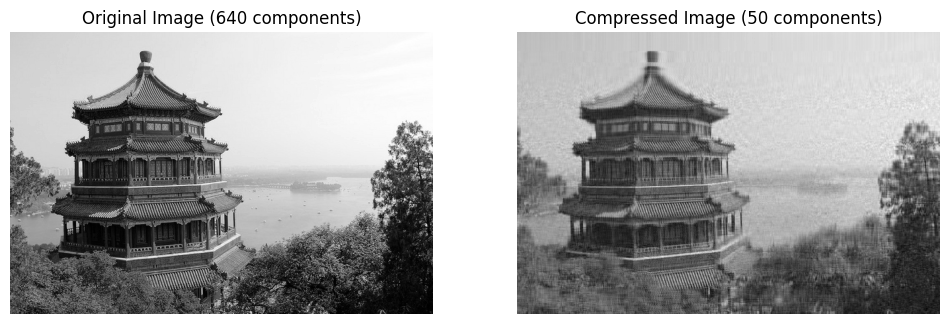

By keeping only 50 components, we retain 95.17% of the original image's information!


In [24]:
# Load sample scikit-learn image and convert to grayscale
china = load_sample_image("china.jpg")
china_gray = china.mean(axis=2) # Convert to 2D grayscale array

print(f"Original Image Shape: {china_gray.shape}") # e.g., (427, 640)

# Apply PCA to compress the image (keeping only top 50 components out of 640)
pca_img = PCA(n_components=50)
china_compressed = pca_img.fit_transform(china_gray)

# Reconstruct the image from the compressed version
china_reconstructed = pca_img.inverse_transform(china_compressed)

# Visualizing Original vs Compressed
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(china_gray, cmap='gray')
axes[0].set_title('Original Image (640 components)')
axes[0].axis('off')

axes[1].imshow(china_reconstructed, cmap='gray')
axes[1].set_title('Compressed Image (50 components)')
axes[1].axis('off')

plt.show()

variance_retained = sum(pca_img.explained_variance_ratio_) * 100
print(f"By keeping only 50 components, we retain {variance_retained:.2f}% of the original image's information!")